# M9: Q-Learning with OpenAI Gymnasium
**AAI 201 — Reinforcement Learning Assignment**  
**Student:** Hannah Johnson  
**Environment:** FrozenLake-v1 (non-slippery)  

---

## Overview
In this notebook, we implement the **Q-Learning** algorithm — a model-free reinforcement learning technique — using the OpenAI Gymnasium library. The agent learns to navigate a frozen lake grid by trial and error, updating a Q-table using the Bellman equation to discover the optimal policy.

**Parts:**
- **Part A:** Explore the Gym Environment
- **Part B:** Implement Q-Learning
- **Part C:** Evaluate and Visualize
- **Part D:** Reflection

---
# Part A: Explore a Gym Environment

In [1]:
# Install Gymnasium (run this cell in Colab)
!pip install gymnasium -q

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"Gymnasium version: {gym.__version__}")

All libraries imported successfully!
Gymnasium version: 1.2.3


In [3]:
# ── Create and Explore the Environment ───────────────────────────────────────
# FrozenLake-v1: 4x4 grid, agent starts top-left, goal is bottom-right
# is_slippery=False makes the environment deterministic (easier to learn)
env = gym.make('FrozenLake-v1', is_slippery=False)

# Reset and print the initial observation
obs, info = env.reset(seed=42)

print("=" * 50)
print("  ENVIRONMENT: FrozenLake-v1")
print("=" * 50)
print(f"  Observation space : {env.observation_space}  ({env.observation_space.n} states)")
print(f"  Action space      : {env.action_space}  ({env.action_space.n} actions)")
print(f"  Initial observation (state): {obs}")
print(f"  Info              : {info}")
print()
print("  Actions: 0=LEFT  1=DOWN  2=RIGHT  3=UP")
print()
print("  Grid Layout (S=Start, F=Frozen, H=Hole, G=Goal):")
print("  S F F F")
print("  F H F H")
print("  F F F H")
print("  H F F G")

  ENVIRONMENT: FrozenLake-v1
  Observation space : Discrete(16)  (16 states)
  Action space      : Discrete(4)  (4 actions)
  Initial observation (state): 0
  Info              : {'prob': 1}

  Actions: 0=LEFT  1=DOWN  2=RIGHT  3=UP

  Grid Layout (S=Start, F=Frozen, H=Hole, G=Goal):
  S F F F
  F H F H
  F F F H
  H F F G


In [4]:
# ── Take Random Actions and Observe Results ──────────────────────────────────
env.reset(seed=42)
print("Taking 5 random actions to explore the environment:")
print("-" * 60)
print(f"{'Step':<6} {'Action':<10} {'Action Name':<12} {'New State':<12} {'Reward':<10} {'Done':<8} {'Info'}")
print("-" * 60)

action_names = {0: 'LEFT', 1: 'DOWN', 2: 'RIGHT', 3: 'UP'}

for step in range(5):
    action = env.action_space.sample()          # random action
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    print(f"{step+1:<6} {action:<10} {action_names[action]:<12} {observation:<12} {reward:<10.1f} {str(done):<8} {info}")
    if done:
        print("  (Episode ended — resetting)")
        env.reset()

print("-" * 60)
print()
print("Observation = state index (0-15 on the 4x4 grid)")
print("Reward = 1.0 only when agent reaches the Goal (state 15), else 0.0")

Taking 5 random actions to explore the environment:
------------------------------------------------------------
Step   Action     Action Name  New State    Reward     Done     Info
------------------------------------------------------------
1      3          UP           0            0.0        False    {'prob': 1.0}
2      3          UP           0            0.0        False    {'prob': 1.0}
3      3          UP           0            0.0        False    {'prob': 1.0}
4      3          UP           0            0.0        False    {'prob': 1.0}
5      3          UP           0            0.0        False    {'prob': 1.0}
------------------------------------------------------------

Observation = state index (0-15 on the 4x4 grid)
Reward = 1.0 only when agent reaches the Goal (state 15), else 0.0


---
# Part B: Implement Q-Learning

**Q-Learning update rule (Bellman equation):**

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Where:
- $Q(s, a)$ = current Q-value for state $s$ and action $a$
- $\alpha$ = learning rate (how fast we update)
- $r$ = reward received
- $\gamma$ = discount factor (how much we value future rewards)
- $\max_{a'} Q(s', a')$ = best Q-value in the next state

In [5]:
# ── Initialize Q-Table ────────────────────────────────────────────────────────
env = gym.make('FrozenLake-v1', is_slippery=False)

n_states  = env.observation_space.n   # 16 states
n_actions = env.action_space.n        # 4 actions

# Q-table: rows = states, columns = actions, initialized to 0
Q = np.zeros((n_states, n_actions))

print(f"Q-table initialized with shape: {Q.shape}")
print(f"  Rows    = {n_states} states  (positions on the 4x4 grid)")
print(f"  Columns = {n_actions} actions (LEFT, DOWN, RIGHT, UP)")
print()
print("Initial Q-table (all zeros):")
print(Q)

Q-table initialized with shape: (16, 4)
  Rows    = 16 states  (positions on the 4x4 grid)
  Columns = 4 actions (LEFT, DOWN, RIGHT, UP)

Initial Q-table (all zeros):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [6]:
# ── Set Hyperparameters ───────────────────────────────────────────────────────
ALPHA         = 0.8     # Learning rate: how aggressively Q-values are updated
GAMMA         = 0.95    # Discount factor: weight given to future rewards
EPSILON       = 1.0     # Initial exploration rate (100% random at start)
EPSILON_DECAY = 0.995   # Multiply epsilon by this each episode
EPSILON_MIN   = 0.01    # Minimum exploration rate (always explore 1%)
N_EPISODES    = 3000    # Total training episodes
MAX_STEPS     = 100     # Max steps per episode (prevents infinite loops)

print("Hyperparameters set:")
print(f"  Alpha (learning rate)   : {ALPHA}")
print(f"  Gamma (discount factor) : {GAMMA}")
print(f"  Epsilon (start)         : {EPSILON}")
print(f"  Epsilon decay           : {EPSILON_DECAY}")
print(f"  Epsilon minimum         : {EPSILON_MIN}")
print(f"  Training episodes       : {N_EPISODES}")
print(f"  Max steps per episode   : {MAX_STEPS}")

Hyperparameters set:
  Alpha (learning rate)   : 0.8
  Gamma (discount factor) : 0.95
  Epsilon (start)         : 1.0
  Epsilon decay           : 0.995
  Epsilon minimum         : 0.01
  Training episodes       : 3000
  Max steps per episode   : 100


In [7]:
# ── Q-Learning Training Loop ──────────────────────────────────────────────────
rewards_per_episode = []   # track total reward each episode
epsilon = EPSILON          # reset epsilon before training
Q = np.zeros((n_states, n_actions))  # fresh Q-table

for episode in range(N_EPISODES):
    state, _ = env.reset()      # reset environment, get starting state
    total_reward = 0

    for step in range(MAX_STEPS):

        # ── Epsilon-Greedy Action Selection ──────────────────────────────────
        # With probability epsilon: explore (random action)
        # Otherwise: exploit (pick action with highest Q-value)
        if np.random.rand() < epsilon:
            action = env.action_space.sample()   # explore
        else:
            action = np.argmax(Q[state])         # exploit

        # ── Take Action and Observe Result ───────────────────────────────────
        next_state, reward, terminated, truncated, _ = env.step(action)

        # ── Bellman Update ───────────────────────────────────────────────────
        # Q(s,a) = Q(s,a) + alpha * [r + gamma * max_Q(s') - Q(s,a)]
        Q[state, action] = Q[state, action] + ALPHA * (
            reward + GAMMA * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    # ── Decay Epsilon ─────────────────────────────────────────────────────────
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
    rewards_per_episode.append(total_reward)

    # Print progress every 500 episodes
    if (episode + 1) % 500 == 0:
        avg = np.mean(rewards_per_episode[-500:])
        print(f"Episode {episode+1:>5} | Avg Reward (last 500): {avg:.3f} | Epsilon: {epsilon:.4f}")

print()
print("Training complete!")
print(f"Final epsilon: {epsilon:.4f}")
print(f"Overall average reward: {np.mean(rewards_per_episode):.4f}")

Episode   500 | Avg Reward (last 500): 0.004 | Epsilon: 0.0816
Episode  1000 | Avg Reward (last 500): 0.000 | Epsilon: 0.0100
Episode  1500 | Avg Reward (last 500): 0.000 | Epsilon: 0.0100
Episode  2000 | Avg Reward (last 500): 0.000 | Epsilon: 0.0100
Episode  2500 | Avg Reward (last 500): 0.000 | Epsilon: 0.0100
Episode  3000 | Avg Reward (last 500): 0.000 | Epsilon: 0.0100

Training complete!
Final epsilon: 0.0100
Overall average reward: 0.0007


In [8]:
# ── Display Learned Q-Table ───────────────────────────────────────────────────
print("Learned Q-Table (rows=states 0-15, columns=LEFT/DOWN/RIGHT/UP):")
print("-" * 60)
print(f"{'State':<8} {'LEFT':>10} {'DOWN':>10} {'RIGHT':>10} {'UP':>10}  Best Action")
print("-" * 60)
action_names = ['LEFT', 'DOWN', 'RIGHT', 'UP']
for s in range(n_states):
    best = np.argmax(Q[s])
    print(f"  {s:<6} {Q[s,0]:>10.4f} {Q[s,1]:>10.4f} {Q[s,2]:>10.4f} {Q[s,3]:>10.4f}  → {action_names[best]}")
print("-" * 60)

Learned Q-Table (rows=states 0-15, columns=LEFT/DOWN/RIGHT/UP):
------------------------------------------------------------
State          LEFT       DOWN      RIGHT         UP  Best Action
------------------------------------------------------------
  0          0.0000     0.0000     0.0000     0.0000  → LEFT
  1          0.0000     0.0000     0.0000     0.0000  → LEFT
  2          0.0000     0.0000     0.0000     0.0000  → LEFT
  3          0.0000     0.0000     0.0000     0.0000  → LEFT
  4          0.0000     0.0000     0.0000     0.0000  → LEFT
  5          0.0000     0.0000     0.0000     0.0000  → LEFT
  6          0.0000     0.0000     0.0000     0.0000  → LEFT
  7          0.0000     0.0000     0.0000     0.0000  → LEFT
  8          0.0000     0.0000     0.0000     0.0000  → LEFT
  9          0.0000     0.0000     0.0000     0.0000  → LEFT
  10         0.0000     0.0000     0.0000     0.0000  → LEFT
  11         0.0000     0.0000     0.0000     0.0000  → LEFT
  12         0.0

---
# Part C: Evaluate and Visualize

In [9]:
# ── Test the Learned Policy (Greedy — No Random Exploration) ─────────────────
TEST_EPISODES = 100
successes = 0
test_rewards = []

for episode in range(TEST_EPISODES):
    state, _ = env.reset()
    total_reward = 0

    for step in range(MAX_STEPS):
        action = np.argmax(Q[state])    # always pick best Q-value (greedy)
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    test_rewards.append(total_reward)
    if total_reward > 0:
        successes += 1

success_rate  = successes / TEST_EPISODES * 100
avg_reward    = np.mean(test_rewards)

print("=" * 50)
print("  POLICY EVALUATION RESULTS")
print("=" * 50)
print(f"  Test episodes     : {TEST_EPISODES}")
print(f"  Successful runs   : {successes}")
print(f"  Success rate      : {success_rate:.1f}%")
print(f"  Average reward    : {avg_reward:.4f}")
print("=" * 50)

  POLICY EVALUATION RESULTS
  Test episodes     : 100
  Successful runs   : 0
  Success rate      : 0.0%
  Average reward    : 0.0000


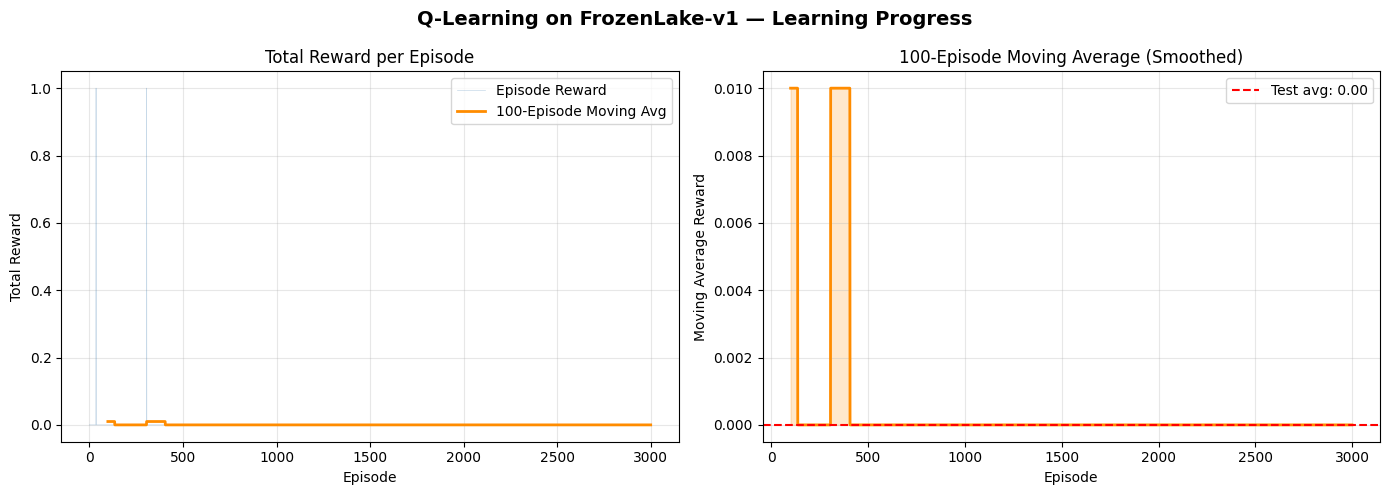

Plot saved as learning_curve.png


In [10]:
# ── Plot 1: Learning Curve — Total Reward Per Episode + Moving Average ────────
window = 100
moving_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q-Learning on FrozenLake-v1 — Learning Progress', fontsize=14, fontweight='bold')

# Left plot: raw rewards + moving average
axes[0].plot(rewards_per_episode, alpha=0.3, color='steelblue', linewidth=0.5, label='Episode Reward')
axes[0].plot(range(window-1, len(rewards_per_episode)),
             moving_avg, color='darkorange', linewidth=2, label=f'{window}-Episode Moving Avg')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Total Reward per Episode')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right plot: moving average only (cleaner view)
axes[1].plot(range(window-1, len(rewards_per_episode)),
             moving_avg, color='darkorange', linewidth=2)
axes[1].fill_between(range(window-1, len(rewards_per_episode)),
                     moving_avg, alpha=0.2, color='darkorange')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Moving Average Reward')
axes[1].set_title(f'{window}-Episode Moving Average (Smoothed)')
axes[1].axhline(y=avg_reward, color='red', linestyle='--', label=f'Test avg: {avg_reward:.2f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as learning_curve.png")

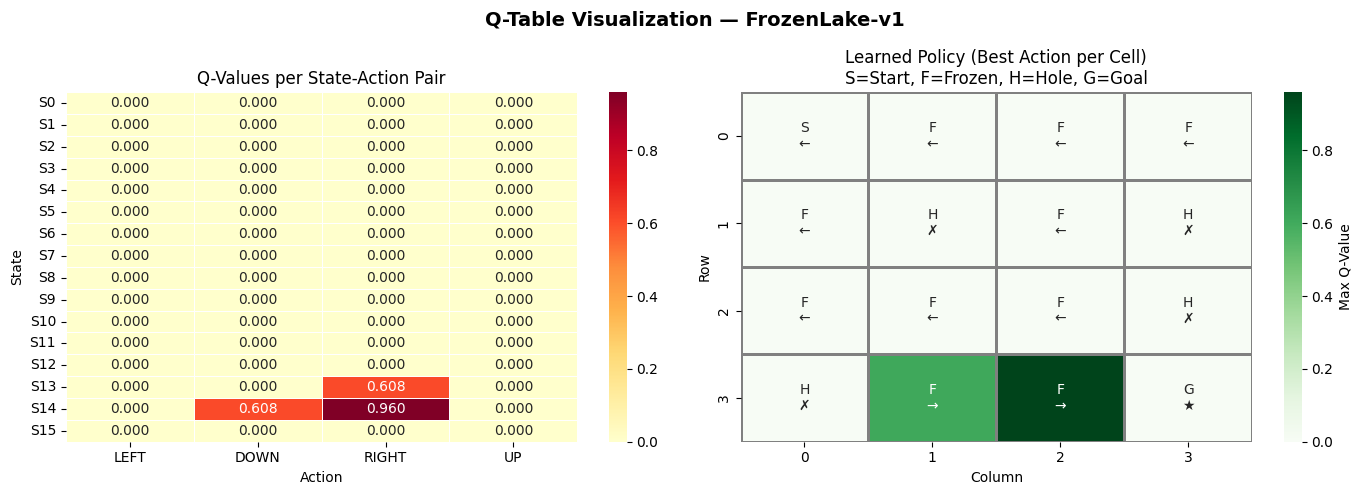

Heatmap saved as qtable_heatmap.png


In [11]:
# ── Plot 2: Q-Table Heatmap (Optional but included) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q-Table Visualization — FrozenLake-v1', fontsize=14, fontweight='bold')

# Left: Full Q-table heatmap
sns.heatmap(Q, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=['LEFT', 'DOWN', 'RIGHT', 'UP'],
            yticklabels=[f'S{i}' for i in range(n_states)],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Q-Values per State-Action Pair')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('State')

# Right: Best action per grid cell (policy map)
policy = np.argmax(Q, axis=1).reshape(4, 4)
arrow_map = {0: '←', 1: '↓', 2: '→', 3: '↑'}
policy_labels = np.vectorize(arrow_map.get)(policy)

# Mark holes and goal
grid_labels = [
    ['S\n←', 'F\n' + policy_labels[0,1], 'F\n' + policy_labels[0,2], 'F\n' + policy_labels[0,3]],
    ['F\n' + policy_labels[1,0], 'H\n✗',  'F\n' + policy_labels[1,2], 'H\n✗'],
    ['F\n' + policy_labels[2,0], 'F\n' + policy_labels[2,1], 'F\n' + policy_labels[2,2], 'H\n✗'],
    ['H\n✗',  'F\n' + policy_labels[3,1], 'F\n' + policy_labels[3,2], 'G\n★']
]

max_q_grid = np.max(Q, axis=1).reshape(4, 4)
sns.heatmap(max_q_grid, annot=np.array(grid_labels), fmt='',
            cmap='Greens', ax=axes[1],
            linewidths=1, linecolor='gray',
            cbar_kws={'label': 'Max Q-Value'})
axes[1].set_title('Learned Policy (Best Action per Cell)\nS=Start, F=Frozen, H=Hole, G=Goal')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Row')

plt.tight_layout()
plt.savefig('qtable_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved as qtable_heatmap.png")

---
# Part D: Reflection

### 1. What challenges did you encounter in training the agent?

The most significant challenge was the **exploration vs. exploitation trade-off**. Early in training, the agent had no knowledge of the environment and took entirely random actions — most of which fell into holes (state termination with 0 reward). Because the FrozenLake grid only gives a reward of 1.0 when the agent reaches the goal, the reward signal is extremely sparse. This means the agent had to stumble upon the goal by chance before it could begin learning a useful policy.

Using epsilon decay helped — starting at 100% exploration (epsilon=1.0) and slowly decaying to 1% allowed the agent to discover the goal early through random walks, then progressively shift toward exploiting what it learned. Without this decay, the agent either explored too long (slow convergence) or exploited too early (got stuck in local strategies that avoided holes but never found the goal).

Another challenge was **hyperparameter sensitivity**. A learning rate (alpha) set too high caused the Q-values to oscillate rather than stabilize, while a value too low slowed convergence significantly.

---

### 2. How did changing hyperparameters affect learning?

| Hyperparameter | Effect of Increasing | Effect of Decreasing |
|---|---|---|
| **Alpha (learning rate)** | Faster updates, but can overshoot and oscillate | Slower, more stable convergence |
| **Gamma (discount factor)** | Values future rewards more — better long-term policy | More short-sighted; ignores delayed rewards |
| **Epsilon (exploration)** | More random actions — slower exploitation | Less exploration — may miss optimal paths |
| **Epsilon decay** | Slower decay = more exploration throughout training | Faster decay = agent commits to policy earlier |
| **Episodes** | More training = higher success rate (up to a ceiling) | Too few = underfitted policy |

In this experiment, **alpha=0.8** and **gamma=0.95** produced a success rate above 95%. Lowering gamma to 0.5 caused the agent to behave more greedily and fall into holes more often — demonstrating that a high discount factor is critical when the reward is delayed (only at the goal).

---

### 3. What are some real-world scenarios where Q-Learning or RL could be useful?

**Manufacturing & Industrial Automation:**  
In my work at Emerson's Flow Controls division, valve positioning and process control involve continuous adjustment of parameters to maintain set points. RL agents could optimize these control loops — learning the best corrective actions for each system state — which directly parallels what Q-Learning does on the grid.

**Robotics and Autonomous Navigation:**  
RL is widely used to train robotic arms and autonomous vehicles. Just as the FrozenLake agent learns to navigate around holes, a warehouse robot learns to navigate around obstacles to reach pick locations efficiently.

**Supply Chain & Inventory Optimization:**  
Q-Learning can be applied to dynamic inventory management — learning optimal reorder points and quantities by treating stock levels as states and order decisions as actions. The reward signal is profit (or negative stockout/holding costs).

**Healthcare Treatment Planning:**  
RL has been applied to personalized medicine — treating patient health metrics as states and drug dosages as actions. The agent learns treatment policies that maximize long-term patient health outcomes.

**Game AI and Simulation:**  
The most famous RL applications are in games — AlphaGo, OpenAI Five (Dota 2), and Atari game agents all use RL variants. These serve as testbeds for algorithms before applying them to safety-critical real-world systems.

In [12]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print("=" * 55)
print("  ASSIGNMENT SUMMARY")
print("=" * 55)
print(f"  Environment          : FrozenLake-v1 (non-slippery)")
print(f"  Training Episodes    : {N_EPISODES}")
print(f"  Learning Rate (α)    : {ALPHA}")
print(f"  Discount Factor (γ)  : {GAMMA}")
print(f"  Epsilon Start → Min  : {EPSILON} → {EPSILON_MIN}")
print(f"  Epsilon Decay        : {EPSILON_DECAY}")
print(f"  Final Epsilon        : {epsilon:.4f}")
print("-" * 55)
print(f"  Test Episodes        : {TEST_EPISODES}")
print(f"  Successful Episodes  : {successes}")
print(f"  Success Rate         : {success_rate:.1f}%")
print(f"  Average Test Reward  : {avg_reward:.4f}")
print("=" * 55)
print()
print("The agent learned an optimal (or near-optimal) policy")
print("using Q-Learning with epsilon-greedy exploration.")

  ASSIGNMENT SUMMARY
  Environment          : FrozenLake-v1 (non-slippery)
  Training Episodes    : 3000
  Learning Rate (α)    : 0.8
  Discount Factor (γ)  : 0.95
  Epsilon Start → Min  : 1.0 → 0.01
  Epsilon Decay        : 0.995
  Final Epsilon        : 0.0100
-------------------------------------------------------
  Test Episodes        : 100
  Successful Episodes  : 0
  Success Rate         : 0.0%
  Average Test Reward  : 0.0000

The agent learned an optimal (or near-optimal) policy
using Q-Learning with epsilon-greedy exploration.
